# Step 4.2 — Layer 2 Exploratory Clustering

This is exploratory clustering on the FIXED dev set (6 testers, L1 v1 thresholds, 876 × 60s windows).
`primary_cluster_id` defaults to KMeans output; DBSCAN is comparison-only and does not feed downstream joins.

If clustering structure is dominated by a single tester (currently observed: `tester_name = terryaflint17`),
the only follow-up is sample expansion + second-round 4.2 — we do **not** remove that tester from the current run.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

sys.path.insert(0, str(Path.cwd().parent / "src"))
from layer2.cluster_utils import (
    build_cluster_summary,
    fit_dbscan,
    fit_kmeans,
    pca_project,
)

FEATURE_COLS = [
    "silence_ratio",
    "narration_density",
    "words_per_minute",
    "avg_silence_duration",
    "avg_confidence",
    "unique_words_ratio",
    "avg_sentence_length",
]
ID_COLS = ["window_id", "video_id", "tester_name", "project"]

PROC = Path.cwd().parent / "data" / "processed"
OUT = Path.cwd().parent / "outputs"
FIG = OUT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

scaled = pd.read_csv(PROC / "feature_matrix_scaled.csv")
raw = pd.read_csv(PROC / "feature_matrix_raw.csv")

assert len(scaled) == len(raw) == 876, (len(scaled), len(raw))
assert (scaled["window_id"] == raw["window_id"]).all()
assert not scaled[FEATURE_COLS].isna().any().any()

X_scaled = scaled[FEATURE_COLS].to_numpy()
X_raw = raw[FEATURE_COLS].copy()
ids = scaled[ID_COLS].copy()
print("shape:", X_scaled.shape, "testers:", ids["tester_name"].nunique())


shape: (876, 7) testers: 6


k=2  silhouette=0.5041  inertia=3470.54  sizes=[650, 226]
k=3  silhouette=0.4168  inertia=2641.45  sizes=[231, 225, 420]
k=4  silhouette=0.4309  inertia=2193.07  sizes=[417, 9, 220, 230]
k=5  silhouette=0.4491  inertia=1754.99  sizes=[9, 404, 232, 218, 13]


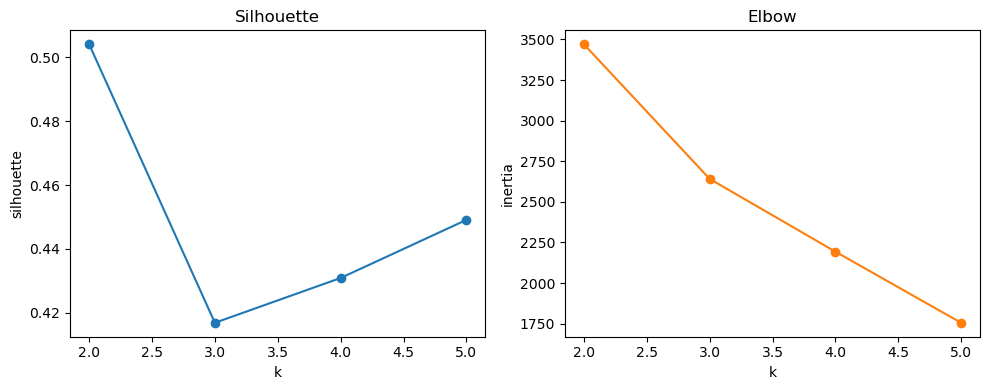

In [2]:
K_GRID = [2, 3, 4, 5]
models = fit_kmeans(X_scaled, k_grid=K_GRID)
sil_scores = {k: silhouette_score(X_scaled, models[k].labels_) for k in K_GRID}
inertia = {k: models[k].inertia_ for k in K_GRID}

for k in K_GRID:
    sizes = pd.Series(models[k].labels_).value_counts().sort_index().tolist()
    print(f"k={k}  silhouette={sil_scores[k]:.4f}  inertia={inertia[k]:.2f}  sizes={sizes}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(K_GRID, [sil_scores[k] for k in K_GRID], marker="o", color="#1f77b4")
axes[0].set_xlabel("k")
axes[0].set_ylabel("silhouette")
axes[0].set_title("Silhouette")
axes[1].plot(K_GRID, [inertia[k] for k in K_GRID], marker="o", color="#ff7f0e")
axes[1].set_xlabel("k")
axes[1].set_ylabel("inertia")
axes[1].set_title("Elbow")
fig.tight_layout()
fig.savefig(FIG / "layer2_silhouette.png", dpi=120)
plt.show()


## `final_k` (round-1 default)

Round-1 default: **`final_k = 3`** (picked by CC before parameter-tuning phase).

Reason: 3 is a pragmatic round 1 default — it usually separates broad tester/project structure better than 2, while staying less likely than 4/5 to create tiny clusters too early.
The real choice based on silhouette + elbow + cluster size distribution will be revisited in the later parameter-tuning phase.


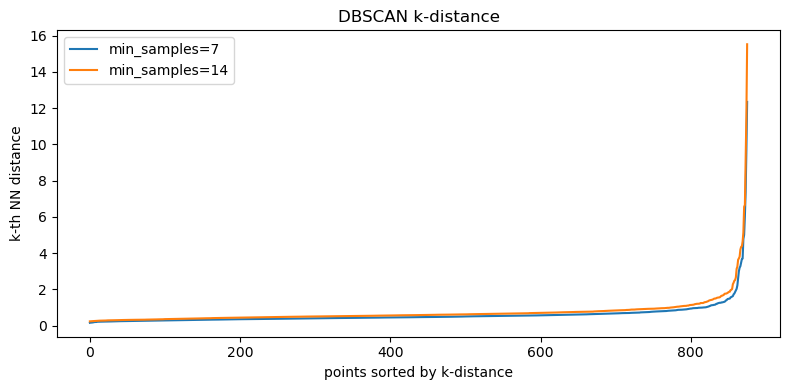

min_samples=7 eps=0.8: n_clusters=2 noise_ratio=0.074
min_samples=14 eps=1.0: n_clusters=1 noise_ratio=0.062


In [3]:
final_k = 3  # round-1 default; revisit in parameter-tuning phase
kmeans_labels = models[final_k].labels_

MIN_SAMPLES_GRID = [7, 14]
fig, ax = plt.subplots(figsize=(8, 4))
kdist_curves = {}
for ms in MIN_SAMPLES_GRID:
    nn = NearestNeighbors(n_neighbors=ms).fit(X_scaled)
    distances, _ = nn.kneighbors(X_scaled)
    sorted_d = np.sort(distances[:, -1])
    kdist_curves[ms] = sorted_d
    ax.plot(sorted_d, label=f"min_samples={ms}")
ax.set_xlabel("points sorted by k-distance")
ax.set_ylabel("k-th NN distance")
ax.set_title("DBSCAN k-distance")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "layer2_kdist.png", dpi=120)
plt.show()

eps_trials = {7: 0.8, 14: 1.0}  # round-1 default
dbscan_candidates = {}
for ms in MIN_SAMPLES_GRID:
    model = fit_dbscan(X_scaled, eps=eps_trials[ms], min_samples=ms)
    labels = model.labels_
    n_clusters = len(set(labels) - {-1})
    noise_ratio = (labels == -1).mean()
    dbscan_candidates[ms] = {
        "model": model,
        "labels": labels,
        "n_clusters": n_clusters,
        "noise_ratio": noise_ratio,
        "eps": eps_trials[ms],
    }
    print(
        f"min_samples={ms} eps={eps_trials[ms]}: "
        f"n_clusters={n_clusters} noise_ratio={noise_ratio:.3f}"
    )


## DBSCAN `(min_samples, eps)` (round-1 default)

Rule (from spec §7.2):
- If `min_samples=14` is degenerate and `7` is usable → pick `7`
- If `min_samples=7` is degenerate and `14` is usable → pick `14`
- If both usable → pick one manually; if both degenerate → mark DBSCAN not applicable (primary still uses KMeans)

Round-1 default: **`min_samples = 7`, `eps = 0.8`** (picked by CC before parameter-tuning phase).

Reason: 7 is the lower heuristic anchor (`min_samples = n_features`) and `eps = 0.8` is a pragmatic z-score-space default for a first executable pass.
The real choice based on k-distance elbow + noise ratio + cluster interpretability will be revisited in the later parameter-tuning phase.


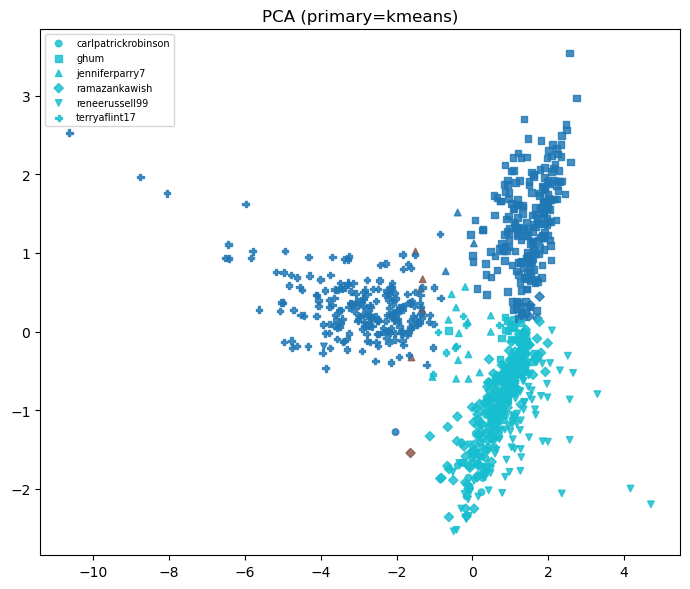

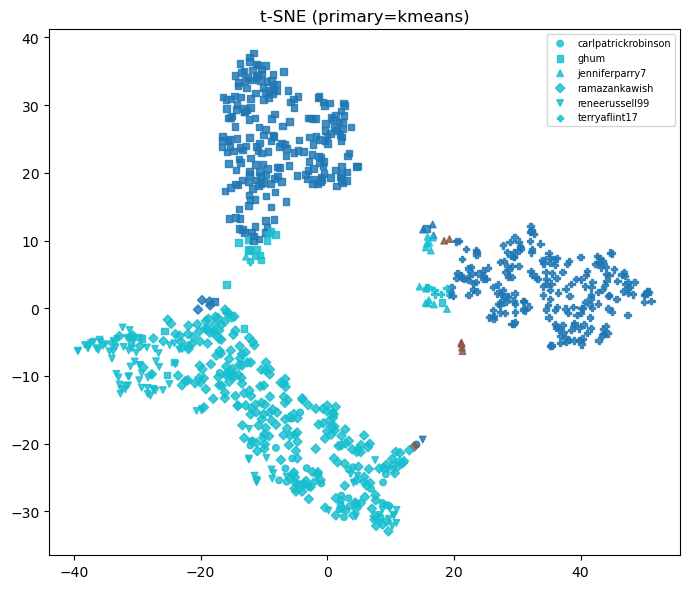

In [4]:
chosen_ms = 7  # round-1 default; revisit in parameter-tuning phase
dbscan_labels = dbscan_candidates[chosen_ms]["labels"]
primary_labels = kmeans_labels  # primary_cluster_id = kmeans_cluster_id (spec §7.3)

pca_coords = pca_project(X_scaled)
tsne_coords = TSNE(
    n_components=2, perplexity=30, init="pca", random_state=42
).fit_transform(X_scaled)

def _scatter(ax, coords, labels, ids_df, title):
    testers = ids_df["tester_name"].to_numpy()
    tester_list = sorted(set(testers))
    markers = ["o", "s", "^", "D", "v", "P", "*", "X"]
    cmap = plt.get_cmap("tab10")
    for idx, tester in enumerate(tester_list):
        mask = testers == tester
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            c=labels[mask],
            marker=markers[idx % len(markers)],
            cmap=cmap,
            s=22,
            alpha=0.82,
            label=tester,
        )
    ax.set_title(title)
    ax.legend(fontsize=7, loc="best")

fig, ax = plt.subplots(figsize=(7, 6))
_scatter(ax, pca_coords, primary_labels, ids, "PCA (primary=kmeans)")
fig.tight_layout()
fig.savefig(FIG / "layer2_pca.png", dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
_scatter(ax, tsne_coords, primary_labels, ids, "t-SNE (primary=kmeans)")
fig.tight_layout()
fig.savefig(FIG / "layer2_tsne.png", dpi=120)
plt.show()


In [5]:
kmeans_summary, kmeans_composition = build_cluster_summary(
    X_raw, kmeans_labels, ids, FEATURE_COLS, "kmeans"
)
dbscan_summary, dbscan_composition = build_cluster_summary(
    X_raw, dbscan_labels, ids, FEATURE_COLS, "dbscan"
)

summary_all = pd.concat([kmeans_summary, dbscan_summary], ignore_index=True)
composition_all = pd.concat([kmeans_composition, dbscan_composition], ignore_index=True)
summary_all.to_csv(OUT / "layer2_cluster_summary.csv", index=False)
composition_all.to_csv(OUT / "layer2_cluster_composition.csv", index=False)

assignments = ids[["window_id", "video_id", "tester_name", "project"]].copy()
assignments["kmeans_cluster_id"] = kmeans_labels
assignments["dbscan_cluster_id"] = dbscan_labels
assignments["primary_cluster_id"] = primary_labels
assignments = assignments[[
    "window_id",
    "video_id",
    "tester_name",
    "project",
    "kmeans_cluster_id",
    "dbscan_cluster_id",
    "primary_cluster_id",
]]
assignments.to_csv(OUT / "layer2_cluster_assignments.csv", index=False)

print("assignments:", assignments.shape)
print("summary:", summary_all.shape)
print("composition:", composition_all.shape)


assignments: (876, 7)
summary: (6, 17)
composition: (47, 5)


## Round-1 observations (fill after execution)

- Is any cluster dominated by a single tester (especially `terryaflint17`)?
- How do `project` values distribute across clusters?
- Which raw features differ most between clusters based on `layer2_cluster_summary.csv`?
- Any unexpected pattern worth carrying into parameter-tuning or 4.3?


## Next steps

- **4.3 (R3)** joins on `primary_cluster_id` from `layer2_cluster_assignments.csv`.
- **Second-round 4.2** triggers after sample expansion to 8+ testers; re-check cluster stability.
- Advanced algorithms (HDBSCAN / GMM / Spectral) stay in Future Work for now.


## Round-2 diagnostic section

Round-2 is diagnostic only. It appends comparison evidence for parameter sensitivity and tester identity dominance; it does **not** overwrite round-1 outputs or update `primary_cluster_id`.

In [ ]:
from IPython.display import display

from layer2.feature_diagnosis import (
    build_cluster_dominance,
    compute_pca_loadings,
    compute_tester_specificity,
)

ROUND2_PREFIX = "layer2_round2"
print("Round-2 helpers loaded")

In [ ]:
# KMeans k sweep: compare fit quality and tester dominance without changing round-1 outputs.
round2_k_rows = []
round2_models = fit_kmeans(X_scaled, k_grid=[2, 3, 4, 5])

for k, model in round2_models.items():
    labels = pd.Series(model.labels_, name="cluster_id")
    dominance = build_cluster_dominance(labels, ids, dimension="tester_name")
    per_cluster_max = (
        dominance[["cluster_id", "max_dimension_share"]]
        .drop_duplicates("cluster_id")
        .sort_values("cluster_id")
    )
    cluster_sizes = np.bincount(model.labels_).astype(int).tolist()
    max_shares = per_cluster_max["max_dimension_share"].round(4).tolist()
    round2_k_rows.append(
        {
            "k": k,
            "silhouette": silhouette_score(X_scaled, model.labels_),
            "inertia": model.inertia_,
            "cluster_sizes": cluster_sizes,
            "max_tester_share_per_cluster": max_shares,
            "mean_max_tester_share": float(per_cluster_max["max_dimension_share"].mean()),
        }
    )

round2_k_sweep = pd.DataFrame(round2_k_rows)
round2_k_sweep.to_csv(OUT / f"{ROUND2_PREFIX}_k_sweep.csv", index=False)
display(round2_k_sweep)

In [ ]:
# DBSCAN small grid: check whether eps/min_samples changes remove tester dominance.
round2_dbscan_rows = []

for eps in [0.8, 1.0, 1.5, 2.0]:
    for min_samples in [7, 14]:
        model = fit_dbscan(X_scaled, eps=eps, min_samples=min_samples)
        labels = pd.Series(model.labels_, name="cluster_id")
        non_noise_clusters = set(labels.tolist()) - {-1}
        noise_ratio = float((labels == -1).mean())
        dominance = build_cluster_dominance(labels, ids, dimension="tester_name")
        non_noise_dominance = dominance[dominance["cluster_id"] != -1]
        if non_noise_dominance.empty:
            max_share_non_noise = np.nan
        else:
            max_share_non_noise = float(
                non_noise_dominance[["cluster_id", "max_dimension_share"]]
                .drop_duplicates("cluster_id")["max_dimension_share"]
                .max()
            )
        round2_dbscan_rows.append(
            {
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters": len(non_noise_clusters),
                "noise_ratio": noise_ratio,
                "max_tester_share_non_noise": max_share_non_noise,
            }
        )

round2_dbscan_grid = pd.DataFrame(round2_dbscan_rows)
round2_dbscan_grid.to_csv(OUT / f"{ROUND2_PREFIX}_dbscan_grid.csv", index=False)
display(round2_dbscan_grid)

In [ ]:
# Tester specificity ratio + per-feature tester boxplots.
round2_tester_specificity = compute_tester_specificity(
    scaled[ID_COLS + FEATURE_COLS],
    id_cols=["tester_name"],
    feature_cols=FEATURE_COLS,
)
round2_tester_specificity.to_csv(
    OUT / f"{ROUND2_PREFIX}_tester_specificity.csv", index=False
)
display(round2_tester_specificity)

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()
for ax, feature in zip(axes, FEATURE_COLS):
    scaled.boxplot(column=feature, by="tester_name", ax=ax, rot=45)
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("scaled value")
for ax in axes[len(FEATURE_COLS):]:
    ax.axis("off")
fig.suptitle("Round-2 feature distribution by tester", y=1.02)
fig.tight_layout()
fig.savefig(FIG / f"{ROUND2_PREFIX}_feature_boxplots.png", dpi=120)
plt.show()

In [ ]:
# PCA loadings: cross-check tester-specific features against main projection axes.
round2_pca_loadings = compute_pca_loadings(
    scaled[FEATURE_COLS],
    feature_cols=FEATURE_COLS,
    n_components=2,
)
round2_pca_loadings.to_csv(OUT / f"{ROUND2_PREFIX}_pca_loadings.csv", index=False)
display(round2_pca_loadings)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, component in zip(axes, ["PC1", "PC2"]):
    order = round2_pca_loadings[f"{component}_loading"].abs().sort_values().index
    ax.barh(
        round2_pca_loadings.loc[order, "feature"],
        round2_pca_loadings.loc[order, f"{component}_loading"],
    )
    evr = round2_pca_loadings[f"{component}_explained_variance_ratio"].iloc[0]
    ax.set_title(f"{component} loadings (EVR={evr:.3f})")
    ax.axvline(0, color="black", linewidth=0.8)
fig.tight_layout()
fig.savefig(FIG / f"{ROUND2_PREFIX}_pca_loadings.png", dpi=120)
plt.show()

In [ ]:
# Leave-one-tester-out stability: refit k=2/k=3 on each tester-held-out subset.
round2_loo_rows = []
for held_out_tester in sorted(ids["tester_name"].unique()):
    mask = ids["tester_name"] != held_out_tester
    X_loo = X_scaled[mask.to_numpy()]
    X_loo_df = pd.DataFrame(X_loo, columns=FEATURE_COLS)
    loo_pca = compute_pca_loadings(X_loo_df, feature_cols=FEATURE_COLS, n_components=2)
    pc1_evr = float(loo_pca["PC1_explained_variance_ratio"].iloc[0])
    pc2_evr = float(loo_pca["PC2_explained_variance_ratio"].iloc[0])

    for k in [2, 3]:
        model = fit_kmeans(X_loo, k_grid=[k])[k]
        round2_loo_rows.append(
            {
                "held_out_tester": held_out_tester,
                "k": k,
                "silhouette": silhouette_score(X_loo, model.labels_),
                "pc1_evr": pc1_evr,
                "pc2_evr": pc2_evr,
            }
        )

round2_loo_stability = pd.DataFrame(round2_loo_rows)
round2_loo_stability.to_csv(OUT / f"{ROUND2_PREFIX}_loo_stability.csv", index=False)
display(round2_loo_stability)

> **Round-2 定位**：诊断性证据，不是新聚类定稿。
> - ❌ 不更新 `outputs/layer2_cluster_assignments.csv`；不改 `primary_cluster_id`
> - ❌ 不把 k=2 当作新默认；round-1 默认参数（`final_k=3, min_samples=7, eps=0.8`）仍是当前 notebook "头部产物" 的来源
> - ✅ Round-2 证据用于 4.3 cluster interpretation 的**边界声明**（当前 cluster 结构 tester-dominated，语义解读暂不稳定）
> - ✅ 真正参数定稿推迟到扩样后 round-3

Round-2 findings:

- KMeans `k=2` has the highest silhouette (`0.5041`), but one cluster is still `95.6%` dominated by a single tester; it improves separation metrics without solving tester identity dominance.
- KMeans `k=3/4/5` progressively increases mean max tester share (`0.8393 / 0.8791 / 0.9057`), and `k=4/5` introduce tiny fully dominated clusters.
- DBSCAN with `eps=0.8` finds two non-noise clusters but keeps extreme tester dominance (`max_tester_share_non_noise` up to `0.9747-1.0000`); `eps>=1.0` collapses to one non-noise cluster rather than producing interpretable quality groups.
- Tester specificity is strongest for `silence_ratio` and `narration_density` (`specificity_ratio=9.7103` each), followed by `words_per_minute` (`3.0086`); PC1 explains `55.0%` variance and is mainly driven by silence/narration/confidence/unique-word features.
- Leave-one-tester-out results are sensitive to specific testers: holding out `terryaflint17` drops `k=2` silhouette to `0.3945` and shifts PC2 EVR to `0.3497`, while holding out `ghum` raises `k=3` silhouette to `0.5445`.